# Sampling, Confidence Intervals, and the Central Limit Theorem

## Purpose and scope

These notes use repeated sampling from a large real dataset to study how sample statistics vary. The full dataset is treated as a finite population, and repeated samples are used to connect empirical simulation with standard statistical formulas.

Main concepts covered:

- population versus sample;
- sample mean and sampling distribution;
- standard deviation versus standard error;
- Central Limit Theorem;
- normal, t-based, and bootstrap confidence intervals;
- confidence-interval coverage;
- uncertainty in subgroup comparisons.

## Prerequisites

Assumed background: pandas, random sampling, histograms, and elementary probability. Confidence intervals are introduced from a practical simulation perspective.

In [ ]:
# Optional installation cell. Uncomment if any package is missing in your environment.
# !pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn ucimlrepo openml

## Problem statement

In data science and machine learning, we usually train and evaluate models on samples, not entire populations. A reported mean accuracy, mean loss, or mean response is uncertain because it depends on the sample.

This notebook asks:

> How does the sample mean behave as sample size increases, and how can we quantify uncertainty around it?

We will use the Adult Income dataset and select a numerical variable such as `hours-per-week` or `age`. The full dataset will be treated as the population for demonstration.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)

from scipy import stats

## Dataset description and source

Dataset: **Adult Income dataset**, loaded directly from the UCI Machine Learning Repository using `pandas.read_csv`.

The dataset contains census-like information such as age, education, occupation, working hours per week, and whether income is above or below 50K. It is realistic because it contains mixed variable types, missing values encoded as question marks, and socio-economic heterogeneity.

In [2]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
url_test = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

train_df = pd.read_csv(
    url_train,
    header=None,
    names=column_names,
    na_values='?',
    skipinitialspace=True
)

test_df = pd.read_csv(
    url_test,
    header=None,
    names=column_names,
    na_values='?',
    skipinitialspace=True,
    comment='|'
)

test_df['income'] = test_df['income'].astype(str).str.replace('.', '', regex=False)
df = pd.concat([train_df, test_df], ignore_index=True)

print('Dataset loaded directly from UCI Adult repository')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype').T)

Dataset loaded directly from UCI Adult repository
Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
dtype,int64,object,int64,object,int64,object,object,object,object,object,int64,int64,int64,object,object


## Data quality check

We inspect missing values and choose a numerical variable for sampling experiments. In this notebook, the full dataset is treated as a finite population. This is a teaching simplification: in real research, even a large dataset may itself be a sample from a larger population.

In [3]:
missing = df.isna().sum().sort_values(ascending=False).to_frame('missing_count')
missing['missing_percent'] = 100 * missing['missing_count'] / len(df)
display(missing.head(15))

numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns:', numeric_cols)

preferred = ['hours-per-week', 'age', 'education-num', 'capital-gain']
variable = next((c for c in preferred if c in numeric_cols), numeric_cols[0])
print('Selected numerical variable:', variable)

population = df[variable].dropna().astype(float).reset_index(drop=True)
N = len(population)
pop_mean = population.mean()
pop_std = population.std(ddof=0)
print(f'Finite population size: {N}')
print(f'Population mean of {variable}: {pop_mean:.4f}')
print(f'Population standard deviation of {variable}: {pop_std:.4f}')

,missing_count,missing_percent
occupation,2809,5.7512
workclass,2799,5.7307
native-country,857,1.7546
age,0,0.0000
fnlwgt,0,0.0000
education,0,0.0000
education-num,0,0.0000
marital-status,0,0.0000
relationship,0,0.0000
race,0,0.0000


Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Selected numerical variable: hours-per-week
Finite population size: 48842
Population mean of hours-per-week: 40.4224
Population standard deviation of hours-per-week: 12.3913


## Compact concept note

The raw variable distribution describes individual observations. The sampling distribution describes a statistic computed from repeated samples, such as the sample mean. The Central Limit Theorem is about the second distribution, not necessarily the first.

For a sample mean, uncertainty is measured by the standard error. When sampling independently from a large population, the standard error is approximately `population standard deviation / sqrt(sample size)`. Since this notebook samples without replacement from a finite dataset, a finite-population correction can also be reported.

## Population distribution

Before looking at sample means, inspect the raw variable. The CLT does **not** say that the raw data must be normally distributed. It says that the sampling distribution of the mean often becomes approximately normal as sample size grows.

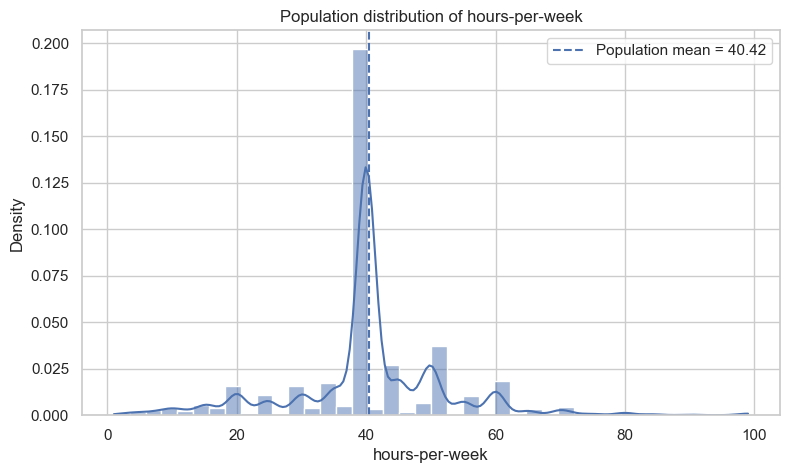

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(population, bins=40, kde=True, stat='density')
plt.axvline(pop_mean, linestyle='--', label=f'Population mean = {pop_mean:.2f}')
plt.title(f'Population distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Density')
plt.legend()
plt.show()

### Interpretation guide

Observe whether the raw variable is symmetric, skewed, or discrete. Even if the raw variable is not normal, repeated sample means can still become approximately normal when sample size is sufficiently large.

## Repeated sampling experiment

For sample sizes 30, 100, 500, and 1000, we repeatedly draw samples and compute the sample mean. This produces an empirical sampling distribution for each sample size.

In [5]:
def repeated_sample_means(data, sample_size, repetitions=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(data)
    means = np.empty(repetitions)
    for i in range(repetitions):
        sample = rng.choice(values, size=sample_size, replace=False)
        means[i] = sample.mean()
    return means

sample_sizes = [30, 100, 500, 1000]
repetitions = 1000
sampling_results = {}

for n in sample_sizes:
    sampling_results[n] = repeated_sample_means(population, n, repetitions, RANDOM_STATE + n)

summary = []
for n, means in sampling_results.items():
    theoretical_se = pop_std / np.sqrt(n)
    fpc_se = theoretical_se * np.sqrt((N - n) / (N - 1))
    summary.append({
        'sample_size': n,
        'mean_of_sample_means': means.mean(),
        'std_of_sample_means_empirical': means.std(ddof=1),
        'theoretical_standard_error_with_replacement': theoretical_se,
        'finite_population_corrected_SE': fpc_se,
        'absolute_error_from_population_mean': abs(means.mean() - pop_mean)
    })

display(pd.DataFrame(summary))

,sample_size,mean_of_sample_means,std_of_sample_means_empirical,theoretical_standard_error_with_replacement,finite_population_corrected_SE,absolute_error_from_population_mean
0,30,40.5139,2.2453,2.2623,2.2617,0.0915
1,100,40.4250,1.2302,1.2391,1.2379,0.0026
2,500,40.4421,0.5445,0.5542,0.5513,0.0197
3,1000,40.4238,0.3863,0.3918,0.3878,0.0014


## Sampling distributions

Each plot below is a distribution of sample means, not a distribution of raw observations. As sample size increases, the distribution should become narrower because the sample mean becomes more stable.

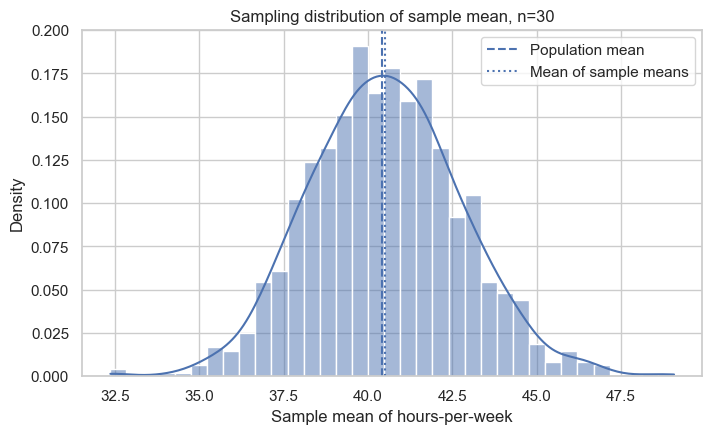

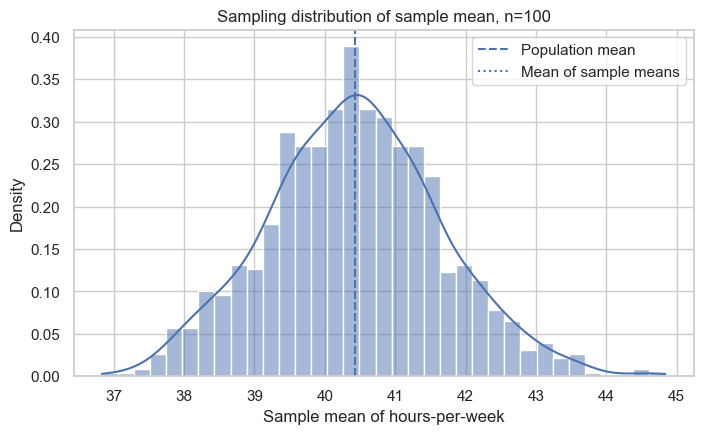

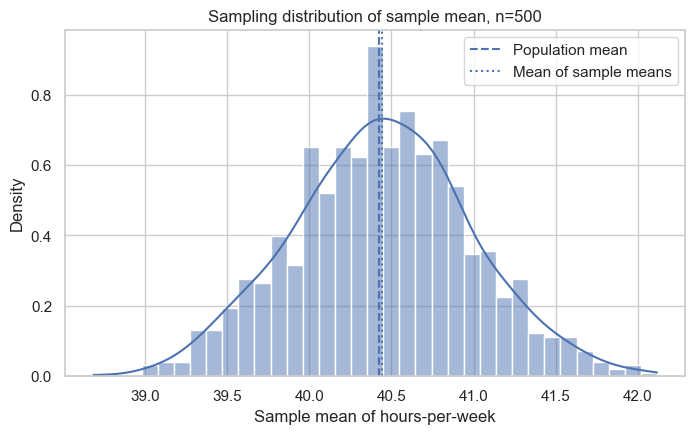

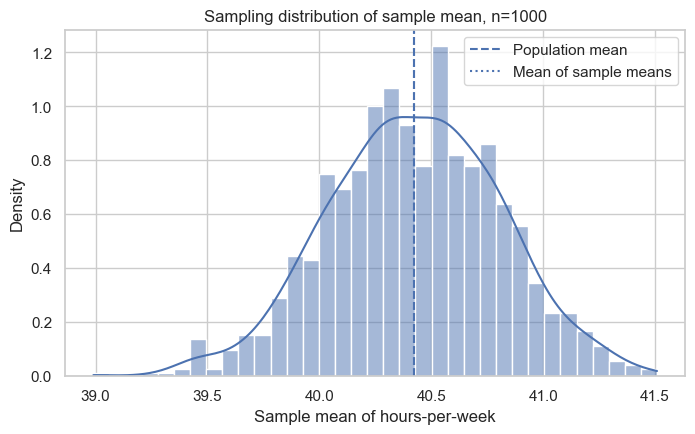

In [6]:
for n, means in sampling_results.items():
    plt.figure(figsize=(8, 4.5))
    sns.histplot(means, bins=35, kde=True, stat='density')
    plt.axvline(pop_mean, linestyle='--', label='Population mean')
    plt.axvline(means.mean(), linestyle=':', label='Mean of sample means')
    plt.title(f'Sampling distribution of sample mean, n={n}')
    plt.xlabel(f'Sample mean of {variable}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

### Interpretation guide

Compare the width of the distributions. The distribution for n=30 should be wider than for n=1000. This narrowing is the effect of the standard error decreasing as sample size increases.

## Standard deviation vs standard error

The standard deviation measures variation among individual observations. The standard error measures uncertainty in a sample statistic, such as the sample mean. They are related but not the same.

,sample_size,standard_error_with_replacement,finite_population_corrected_SE
0,30,2.2623,2.2617
1,100,1.2391,1.2379
2,500,0.5542,0.5513
3,1000,0.3918,0.3878


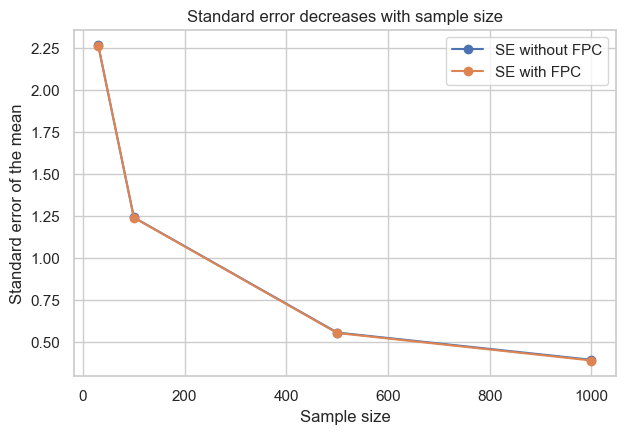

In [7]:
comparison = pd.DataFrame({
    'sample_size': sample_sizes,
    'standard_error_with_replacement': [pop_std / np.sqrt(n) for n in sample_sizes],
    'finite_population_corrected_SE': [
        (pop_std / np.sqrt(n)) * np.sqrt((N - n) / (N - 1)) for n in sample_sizes
    ]
})
display(comparison)

plt.figure(figsize=(7, 4.5))
plt.plot(comparison['sample_size'], comparison['standard_error_with_replacement'], marker='o', label='SE without FPC')
plt.plot(comparison['sample_size'], comparison['finite_population_corrected_SE'], marker='o', label='SE with FPC')
plt.title('Standard error decreases with sample size')
plt.xlabel('Sample size')
plt.ylabel('Standard error of the mean')
plt.legend()
plt.show()

## Confidence interval for one sample

Now we draw one sample and estimate the population mean using three methods:

1. Normal approximation.
2. t-distribution interval.
3. Bootstrap percentile interval.

The t-interval accounts for estimating the standard deviation from the sample.

In [8]:
def ci_normal(sample, confidence=0.95):
    sample = np.asarray(sample)
    mean = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(len(sample))
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    return mean - z * se, mean + z * se

def ci_t(sample, confidence=0.95):
    sample = np.asarray(sample)
    mean = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(len(sample))
    tcrit = stats.t.ppf(1 - (1 - confidence) / 2, df=len(sample) - 1)
    return mean - tcrit * se, mean + tcrit * se

def ci_bootstrap_mean(sample, confidence=0.95, n_boot=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    sample = np.asarray(sample)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        boot_sample = rng.choice(sample, size=len(sample), replace=True)
        boot_means[i] = boot_sample.mean()
    alpha = 1 - confidence
    return np.quantile(boot_means, alpha / 2), np.quantile(boot_means, 1 - alpha / 2), boot_means

n = 100
rng = np.random.default_rng(RANDOM_STATE)
one_sample = rng.choice(population, size=n, replace=False)

normal_ci = ci_normal(one_sample)
t_ci = ci_t(one_sample)
boot_low, boot_high, boot_means = ci_bootstrap_mean(one_sample)

ci_table = pd.DataFrame({
    'method': ['normal approximation', 't-distribution', 'bootstrap percentile'],
    'lower': [normal_ci[0], t_ci[0], boot_low],
    'upper': [normal_ci[1], t_ci[1], boot_high],
    'contains_population_mean': [normal_ci[0] <= pop_mean <= normal_ci[1],
                                 t_ci[0] <= pop_mean <= t_ci[1],
                                 boot_low <= pop_mean <= boot_high]
})
print(f'One sample mean: {one_sample.mean():.4f}')
print(f'Population mean: {pop_mean:.4f}')
display(ci_table)

One sample mean: 39.4900
Population mean: 40.4224


,method,lower,upper,contains_population_mean
0,normal approximation,37.1729,41.8071,True
1,t-distribution,37.1442,41.8358,True
2,bootstrap percentile,37.1495,41.7800,True


### Interpretation guide

A 95% confidence interval procedure means that if we repeated the sampling process many times, about 95% of such intervals would contain the true population mean. After one interval is computed, the population mean is fixed; the interval either contains it or does not.

## Bootstrap distribution

The bootstrap simulates repeated sampling from the observed sample. It is useful when theoretical assumptions are uncertain, but it cannot fix a biased or unrepresentative original sample.

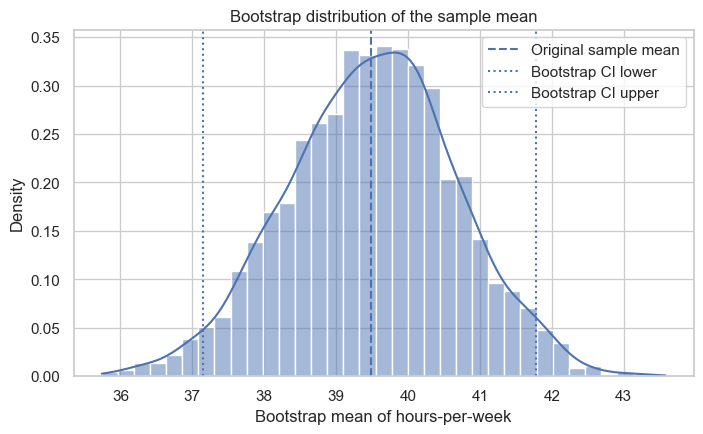

In [9]:
plt.figure(figsize=(8, 4.5))
sns.histplot(boot_means, bins=35, kde=True, stat='density')
plt.axvline(one_sample.mean(), linestyle='--', label='Original sample mean')
plt.axvline(boot_low, linestyle=':', label='Bootstrap CI lower')
plt.axvline(boot_high, linestyle=':', label='Bootstrap CI upper')
plt.title('Bootstrap distribution of the sample mean')
plt.xlabel(f'Bootstrap mean of {variable}')
plt.ylabel('Density')
plt.legend()
plt.show()

## Confidence interval coverage simulation

To understand confidence intervals properly, we repeat the whole sampling process many times and check how often intervals contain the known population mean.

In [10]:
def coverage_simulation(data, sample_size=100, repetitions=500, method='t', random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(data)
    contains = []
    widths = []
    for _ in range(repetitions):
        sample = rng.choice(values, size=sample_size, replace=False)
        if method == 'normal':
            lo, hi = ci_normal(sample)
        elif method == 't':
            lo, hi = ci_t(sample)
        else:
            lo, hi, _ = ci_bootstrap_mean(sample, n_boot=500, random_state=int(rng.integers(0, 1_000_000)))
        contains.append(lo <= pop_mean <= hi)
        widths.append(hi - lo)
    return np.mean(contains), np.mean(widths)

coverage_rows = []
for n in [30, 100, 500]:
    for method in ['normal', 't', 'bootstrap']:
        cov, width = coverage_simulation(population, sample_size=n, method=method, repetitions=300, random_state=RANDOM_STATE+n)
        coverage_rows.append({'sample_size': n, 'method': method, 'coverage_rate': cov, 'average_width': width})

display(pd.DataFrame(coverage_rows))

,sample_size,method,coverage_rate,average_width
0,30,normal,0.9333,8.8180
1,30,t,0.9400,9.2016
2,30,bootstrap,0.9067,8.5226
3,100,normal,0.9433,4.8263
4,100,t,0.9500,4.8860
5,100,bootstrap,0.9533,4.7566
6,500,normal,0.9500,2.1775
7,500,t,0.9500,2.1828
8,500,bootstrap,0.9467,2.1580


### Interpretation guide

Coverage rates should be near 0.95 for a well-behaved 95% CI procedure, but finite samples, skewness, and bootstrap randomness can create deviations. Average interval width should decrease as sample size increases.

## Optional group comparison

If the income target is available, compare the selected variable between income groups. This connects sampling uncertainty to practical subgroup comparisons.

Target column: income
<=50K    37155
>50K     11687
Name: income, dtype: int64


,count,mean,std,median
income,,,,
<=50K,37155,38.8400,12.3568,40.0
>50K,11687,45.4529,11.0912,40.0


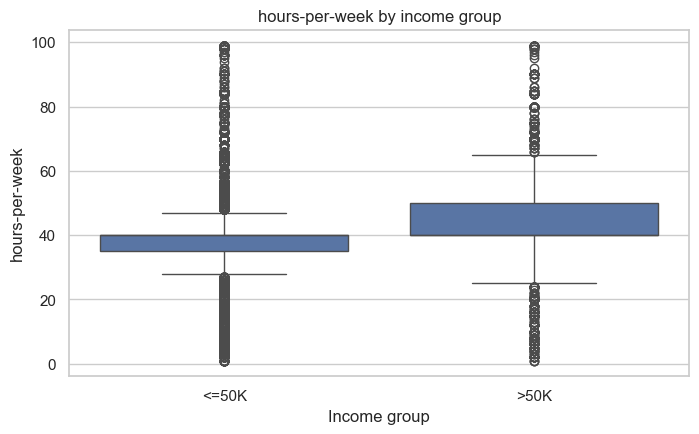

In [11]:
target_col = 'income'

print('Target column:', target_col)
print(df[target_col].value_counts(dropna=False))

group_summary = (
    df[[target_col, variable]]
    .dropna()
    .groupby(target_col)[variable]
    .agg(['count', 'mean', 'std', 'median'])
)
display(group_summary)

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x=target_col, y=variable)
plt.title(f'{variable} by income group')
plt.xlabel('Income group')
plt.ylabel(variable)
plt.show()

## Output-grounded analytical summary

The next cell summarizes the main sampling result using the values computed above. It is useful after re-running the notebook with a different variable or sample-size grid.

In [12]:
sampling_summary = pd.DataFrame(summary).sort_values('sample_size').reset_index(drop=True)
smallest_n = sampling_summary.iloc[0]
largest_n = sampling_summary.iloc[-1]
se_ratio = (
    largest_n['std_of_sample_means_empirical'] /
    smallest_n['std_of_sample_means_empirical']
)

analysis = pd.Series({
    'selected_variable': variable,
    'population_mean': pop_mean,
    'empirical_SE_at_smallest_n': smallest_n['std_of_sample_means_empirical'],
    'empirical_SE_at_largest_n': largest_n['std_of_sample_means_empirical'],
    'largest_over_smallest_SE_ratio': se_ratio,
    'main_interpretation': (
        'The sampling distribution becomes narrower as sample size increases; '
        'this is why larger validation samples give more stable estimates.'
    )
})
display(analysis.to_frame('sampling_diagnostic'))

,sampling_diagnostic
selected_variable,hours-per-week
population_mean,40.4224
empirical_SE_at_smallest_n,2.2453
empirical_SE_at_largest_n,0.3863
largest_over_smallest_SE_ratio,0.1721
main_interpretation,The sampling distribution becomes narrower as ...


## Limitations

- Treating the full Adult dataset as the population is a teaching device; in real studies it is still a sample from a broader society.
- Sampling without replacement creates finite-population effects. They are small here for modest sample sizes but become important when sample size is a large fraction of the population.
- Bootstrap intervals depend on the original sample being representative.
- Confidence intervals quantify sampling uncertainty, not measurement bias, confounding, or dataset shift.

## What we learned

- The CLT concerns the sampling distribution of a statistic, not the raw data distribution.
- Larger samples reduce standard error and make sample means more stable.
- Standard deviation describes individual variability; standard error describes uncertainty in an estimate.
- Normal, t-based, and bootstrap intervals can be similar, but they rely on different assumptions.
- Coverage simulation gives a concrete way to understand what a 95% confidence-interval procedure means.

## Possible extensions

- Repeat the experiment for a highly skewed variable such as capital-gain.
- Compare sampling with and without replacement.
- Build confidence intervals for medians and proportions.
- Apply the same uncertainty logic to model accuracy or F1-score.